LIBRARIES

In [20]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [21]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS =3
CLASS_NAMES =["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [22]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\train",
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (IMG_HEIGHT, IMG_WIDTH)
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\val",
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 16,
    image_size = (IMG_HEIGHT, IMG_WIDTH)
)

normalize = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalize(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [23]:
regularizer = tf.keras.regularizers.l2(0.01)
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    
    keras.layers.Dense(128, kernel_regularizer = regularizer),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.Dropout(0.5),

    keras.layers.Dense (len(CLASS_NAMES), activation ="softmax")

])
model.compile(
    optimizer = "adam",
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

TRAINING

In [24]:
EPOCHS = 10
history =  model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs = EPOCHS,
    #callbacks = [tf.keras.callbacks.EarlyStopping(monitor = "val_accuracy", patience=3, restore_best_weights=True)]
)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.3513 - loss: 5.4292 - val_accuracy: 0.3680 - val_loss: 3.4350
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.3937 - loss: 2.5614 - val_accuracy: 0.2590 - val_loss: 2.5263
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.4120 - loss: 2.1041 - val_accuracy: 0.3930 - val_loss: 2.0451
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.4103 - loss: 2.0358 - val_accuracy: 0.3870 - val_loss: 2.1413
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.4137 - loss: 2.0473 - val_accuracy: 0.3100 - val_loss: 2.2458
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.4227 - loss: 1.9667 - val_accuracy: 0.3400 - val_loss: 2.3405
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.4090 - loss: 1.9905 - val_accuracy: 0.4030 - val_loss: 1.9764
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.4217 - loss: 1.9061 - val_accu

PLOTTING

<function matplotlib.pyplot.show(close=None, block=None)>

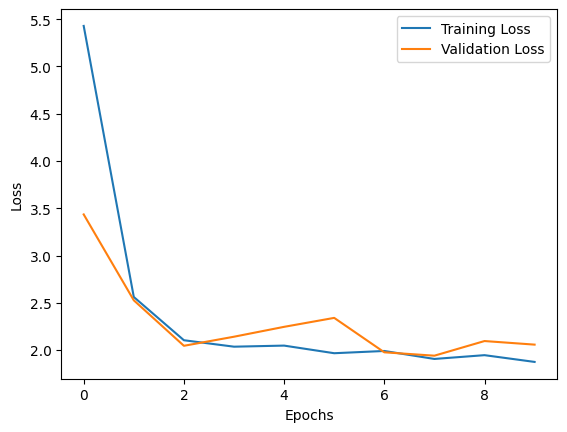

In [25]:
plt.plot(history.history['loss'], label= "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

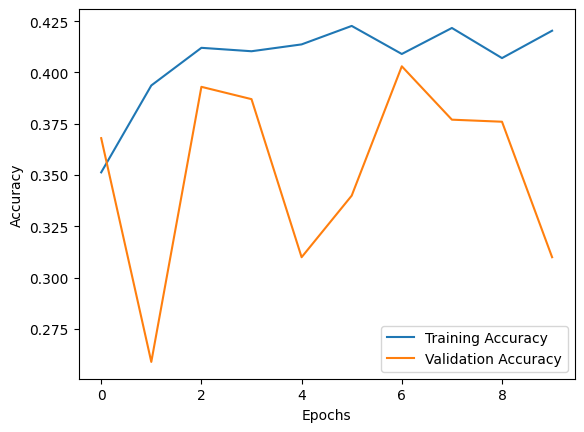

In [26]:
plt.plot(history.history['accuracy'], label= "Training Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.show